<h1 align="center"> <b> Entrega de Procesos Estocásticos </b> </h1>

---
<h2 align="center"> <u> Análisis de la bifurcación supercrítica </u> </h2>

<h3> <b> Enunciado: </b></h3>

Considera la ecuación diferencial estocástica de Stratonovich:

$$
\dot{x}(t) = ax-x^3+\sqrt{D}\xi(t)
$$

donde $\xi(t)$ es un ruido blanco de media cero y correlación $\langle\xi(t)\xi(t')\rangle = \delta(t-t')$. Se te pide:

1. Escribe la correspondiente ecuación de Fokker-Plank
2. Bajo la condición de corriente cero, encuentra la distribución de probabilidad estacionaria $f_{st}(x)$ (no necesitas calcular la ocnstante de normalización).
3. Escribe el potencial para la solución estacionaria.
4. Comenta cómo la forma de la distribución de probabilidad estacionaria varía cal cambiar el parámetro $a$. Comparacon el diagrama de bifurcación de la bifurcación supercrítica de horca (*pitchfork*) $\dot{x}(t) = ax-x^3$.
5. Genera muchas trayectorias del proceso estocástico numéricamente y emplealas para calcular la distribución de probabilidad estacionaria, comparando con la predición teórica.

<h3> <b> Ecuación de Fokker -Plank y distribución de probabilidad estacionaria </b></h3>

Al tratarse de un proceso estocástico de ruido aditivo la ecuación de Fokker-Plank en prescripción Itô o Stratonovich es equivalente, que para una ecuación de Langevin de la forma

$$
\dot{x}(t) = A(x, t) + B(t)\xi(t)
$$

es la siguiente

$$
\frac{\partial f}{\partial t} = -\frac{\partial}{\partial x}\left[ A(x, t)f(x, t) \right] + \frac{1}{2} \frac{\partial^2}{\partial x^2}\left[ B^2(t)f(x, t) \right]
$$

que sustituyendo las expresiones de $A(x, t) = ax-x^3$ y $B(t) = \sqrt{D}$ y distribuyendo la derivada del producto obtenemos

$$
\boxed{
\frac{\partial f}{\partial t} = -\left(a-3x^2\right)f - \left(ax-x^3\right) \frac{\partial f}{\partial x} + \frac{1}{2} D \frac{\partial^2 f}{\partial x^2}
}
$$

Otra forma de la ecuación de Fokker-Plank es la de ecuación de continuidad

$$
\frac{\partial f}{\partial t} = -\frac{\partial J}{\partial x}
$$

donde $J$ es una corriente de probabilidad. El caso $J = 0$ se traduce, por tanto a 

$$
\begin{array}{c}
\left(ax-x^3\right)f_{st}-\frac{1}{2}D\frac{\partial f_{st}}{\partial x} = 0\\
 \Downarrow\\ 
 \frac{d f_{st}}{f_{st}} = \frac{2}{D}\left( ax - x^3\right)dx\\
 \Downarrow\\
 \boxed{
 f_{st}(x) = A\exp\left(2\frac{\frac{1}{2}ax^2-\frac{1}{4}x^4}{D}\right)
 }
 \end{array}
$$

<h3> <b> Potencial: </b></h3>

Suponer que el sistema está sometido a un potencial $V(x)$ significa que la evolución de la posición viene dada por 

$$
\dot{x}(t) = \frac{dV}{dx} +\sqrt{D}\xi(t)
$$

por lo que el equivalente al potencial en este caso sería 

$$
\boxed{
V(x) = -\frac{1}{2}ax^2+\frac{1}{4}x^4
}
$$

Los mínimos del potencial vienen dados por $V'(x) = 0$ y $V''(x) > 0$ que en este caso se dan en 

$$
\begin{cases}
0 \quad , \; a<0\\
\pm \sqrt{a} \quad , \; a\ge 0
\end{cases}
$$

Por lo que cuando $a<0$ aparece tan solo un mínimo estable en $x=0$, mientras que al aumentar $a$ y pasar a ser $a>0$ el punto $x=0$ pasa de ser un mínimo a ser un máximo y aparecen dos mínimos en $a = \pm \sqrt{a}$, un proceso similar a cómo en los sitemas con una bifurcaión de tipo *pitchfork* el punto estable se transfoma en dos estables y uno inestable al variar el parámetro de control. En este caso los puntos fijos estables se corresponden con los mínimos del potencial, que se traducen como máximos en la distribución de probabilidad estacionaria ya que son puntos que *absorben* a los que se encuentran cerca de ellos, y los puntos fijos inestables que son los máximos del potencial, resultan mínimos  de la distribución de probaabilidad ya que *repelen* a los puntos cerca de sí, por lo que dependiendo del valor de $a$ observaremos cómo la pdf pasa de ser monomodal con un solo máximo cuando $a<0$ a ser bimodal con dos máximos en $a>0$.

# Simulación

La siguiente es una simulación interactiva (requiere tener instalado ``ipympl``) en la que se puede observar cómo se obtiene la distribución de probabilida estacionaria teórica cuando $N$ es muy grande y cuando pasa el suficiente tiempo como para que el transitorio desaparezca. En la figura inferior se muestran $N$ partículas cuyo movimiento viene gobernado por la SDE mientras que en la de arriba se muestra el histograma con las posiciones de dichas partículas frente a la distribución de probabilidad teórica para la $a$ y $D$ seleccionadas.

## Parámetros:
- **D**: intensidad del ruido que determina cuan *ancha* es la distribución o si hay mucha difusión debida al ruido.
- **a**: parámetro de control de la distribución que determina si es monomodal o bimodal y cómo de juntos están los picos
- **N**: número de prtículas. Cuando sea umenta $N$ con el deslizador se generan partículas en posiciones dadas por una distribución $\mathcal{N}(0, 1)$.

<div class="alert alert-info">

<b>💡 Tip:</b> es divertido ver cómo al cambiar rápidamente de $ a < 0 $ a $ a > 0 $ las partículas se dividen en dos grupos y cómo al revés van todas *corriendo* al centro a juntarse en torno al máximo de la pdf.

</div>

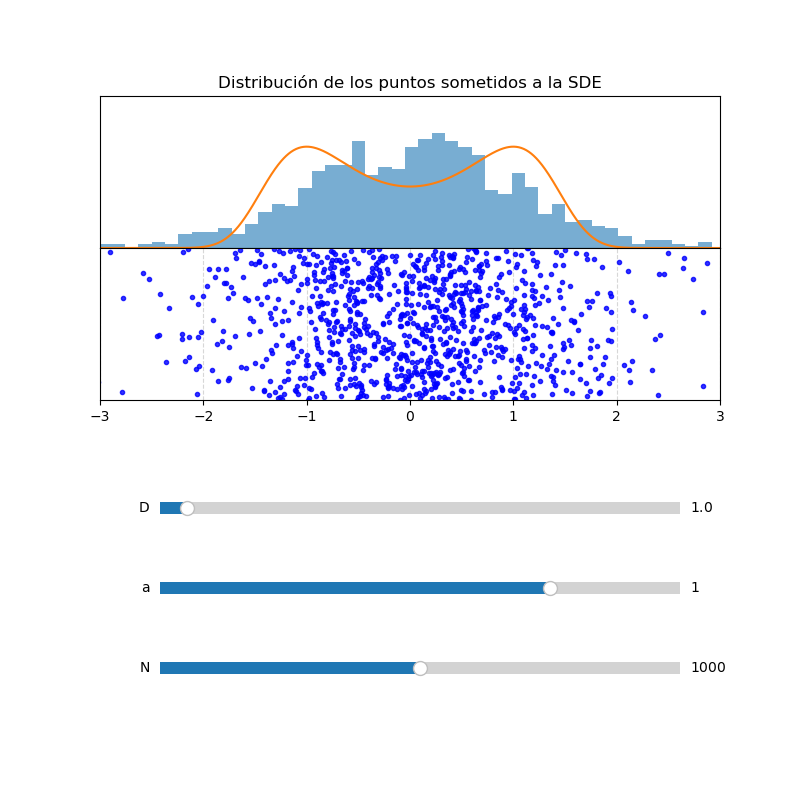

In [ ]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation
from scipy.integrate import quad

# 1. Definimos el sistema de ecuaciones diferenciales estocásticas
def actualizar_posiciones(X, a, D, dt=0.005):
    N = X.shape[0]
    dxdt = a * X - X**3 + np.sqrt(D) * np.random.standard_normal(N) / np.sqrt(dt)
    X_nuevo = X + dt * dxdt

    return X_nuevo

# Configuración inicial de la simulación
N_init = 1000
a_init = 1
D_init = 1
X = np.random.standard_normal(N_init)
Y = np.arange(N_init)

def pdf(x, a, D):
    x_array = np.asarray(x)
    func_nnorm = lambda t: np.exp((a * t**2 - 0.5 * t**4) / D)
    norma, error = quad(func_nnorm, -np.inf, np.inf)
    resultado = func_nnorm(x_array) / norma
    return resultado

# Configuración de la ventana gráfica
plt.close()
fig, [ax_hist, ax_dots] = plt.subplots(nrows=2, figsize=(8, 8))
plt.subplots_adjust(bottom=0.5, hspace=0)

puntos, = ax_dots.plot(X, Y, 'b.', alpha=0.8)
ax_dots.set_xlim(-3, 3)
ax_dots.set_ylim(0, N_init)
ax_dots.grid(True, linestyle='--', alpha=0.5)
ax_dots.set_yticks([])

pesos_iniciales, bins, patches = ax_hist.hist(X, bins=50, density=True, alpha=0.6)
x_range = np.linspace(-3, 3, 1000)
pdf_plot, = ax_hist.plot(x_range, pdf(x_range, a_init, D_init))

ax_hist.set_xlim(-3, 3)
ymax = pdf(x_range, a_init, D_init).max()
ax_hist.set_ylim(0, ymax * 1.5)

ax_hist.set_xticks([])
ax_hist.set_yticks([])
ax_hist.set_title("Simulación interactiva del sistema")

# Creación de los sliders
ax_a = plt.axes([0.2, 0.25, 0.65, 0.03])
ax_D = plt.axes([0.2, 0.35, 0.65, 0.03])
ax_N = plt.axes([0.2, 0.15, 0.65, 0.03])
plt.text(5, 0.1, r"SDE: $\dot{x} = ax-x^3 + \sqrt{D}\xi(t)$", ha='center')

slider_a = Slider(ax=ax_a, label="a", valmin=-2, valmax=2, valinit=a_init)
slider_D = Slider(ax=ax_D, label="D", valmin=0.5, valmax=10, valinit=D_init)
slider_N = Slider(ax=ax_N, label="N", valmin=0, valmax=2000, valinit=N_init, valstep=10)

# Creación de la animación
def update(frame):
    global X, Y
    a = slider_a.val
    D = slider_D.val
    N_actual = len(X)
    N_nuevo = int(slider_N.val)

    if N_nuevo < N_actual:
        X = X[:N_nuevo]
    elif N_nuevo > N_actual:
        N_faltante = N_nuevo - N_actual
        X_faltante = np.random.standard_normal(N_faltante)
        X = np.concatenate((X, X_faltante))

    X = actualizar_posiciones(X, a, D)
    if N_nuevo != N_actual:
        Y = np.arange(N_nuevo)
        if N_nuevo == 0:
            ax_dots.set_ylim(0, 10)
        else:
            ax_dots.set_ylim(0, N_nuevo)

    puntos.set_data(X, Y)
    pdf_plot.set_data(x_range, pdf(x_range, a, D))
    ymax = pdf(x_range, a, D).max()
    ax_hist.set_ylim(0, ymax * 1.5)

    with np.errstate(divide='ignore', invalid='ignore'):
        nuevas_alturas, _ = np.histogram(X, bins=bins, density=True)
    nuevas_alturas = np.nan_to_num(nuevas_alturas)

    for patch, altura in zip(patches, nuevas_alturas):
        patch.set_height(altura)
    
    return puntos, *patches, pdf_plot

animation = FuncAnimation(fig, update, interval=20, cache_frame_data=False)

plt.show()